# Customer Segmentation Using RFM Analysis

## Objective
To segment customers based on purchasing behavior using Recency, Frequency, and Monetary (RFM) analysis and clustering techniques.

## Business Goal
Identify high-value customers, at-risk customers, and low-engagement segments to support targeted marketing strategies.

In [ ]:
# Importing Liberaries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Importing the data

Customer_data = pd.read_csv('E:\\Online Retail Customer Churn\\Data\\online_retail_II.csv')

In [56]:
# Data Understanding and Data Cleaning Start

Customer_data.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [57]:
Customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## 1. Data Cleaning
- Removed missing Customer IDs
- Filtered out negative quantities (returns)
- Created TotalPrice feature

In [58]:
Customer_data.isna().mean()

Invoice        0.000000
StockCode      0.000000
Description    0.004105
Quantity       0.000000
InvoiceDate    0.000000
Price          0.000000
Customer ID    0.227669
Country        0.000000
dtype: float64

In [62]:
Customer_data['InvoiceDate'] = pd.to_datetime(Customer_data['InvoiceDate'])

# Data Cleaning End

In [59]:
Customer_data = Customer_data.drop(columns=['Description', 'StockCode'])
Customer_data = Customer_data.dropna(subset=['Customer ID'])
Customer_data = Customer_data[Customer_data['Quantity'] > 0]

In [60]:
Customer_data.head(2)

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


## 2. Feature Engineering (RFM)
- Recency: Days since last purchase
- Frequency: Number of transactions
- Monetary: Total spend

In [61]:
Customer_data['TotalPrice'] = Customer_data['Quantity'] * Customer_data['Price']

In [63]:
Customer_data.head(2)

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [64]:
# Recency, Frequency, Monetary

referenceDate = Customer_data.InvoiceDate.max()

rfm = Customer_data.groupby('Customer ID').agg({
    'InvoiceDate' : lambda x: (referenceDate - x.max()).days,
    'Invoice' : 'nunique',
    'TotalPrice' : 'sum'}
)

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [65]:
rfm.head(5)

,Customer ID,Recency,Frequency,Monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,309,1,334.40


In [66]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,200.457745,6.287196,3017.076888
std,1715.429759,209.474135,13.012879,14734.128619
min,12346.000000,0.000000,1.000000,0.000000
25%,13833.000000,25.000000,1.000000,347.800000
50%,15313.000000,95.000000,3.000000,897.620000
75%,16797.000000,379.000000,7.000000,2304.180000
max,18287.000000,738.000000,398.000000,608821.650000


## 3. Data Transformation
- Applied log transformation to handle skewness
- Standardized features for clustering

In [67]:
rfm.skew() # Checking the skewness

Customer ID     0.001787
Recency         0.886792
Frequency      12.653997
Monetary       25.320187
dtype: float64

In [68]:
# To avoid/reduce skewness

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

In [69]:
# Creating the RFM Data for Model

rfm_model = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]

In [70]:
# Scaling the data

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_model)

## 4. Clustering (KMeans)
- Used Elbow Method to determine optimal clusters
- Selected k = 4 for interpretability

In [71]:
# Elbow Method for finding the optimal number of clusters

inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

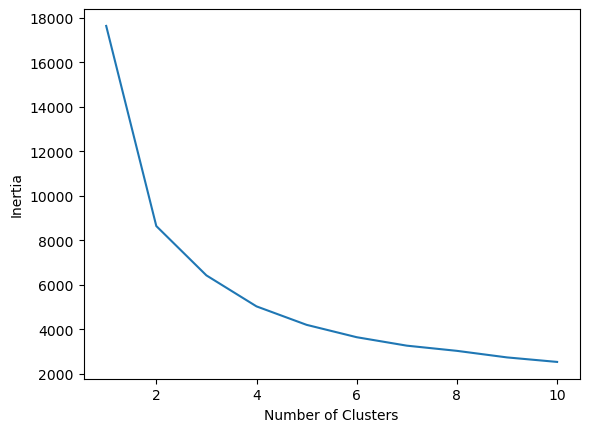

In [72]:
# Plotting the elbow curve

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [73]:
# Final Model for Customer Segmentation

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

## 5. Customer Segmentation
- Assigned business-friendly labels to clusters

In [74]:
# Analyzing the clusters/Customers

rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,26.58,3.03,856.85
1,390.29,1.42,350.93
2,203.95,5.51,2192.06
3,23.91,20.39,11720.66


In [75]:
# Labeling the clusters/Customers

def label_cluster(row):
    if row['Cluster'] == 3:
        return 'Champions'
    elif row['Cluster'] == 2:
        return 'At Risk (High Value)'
    elif row['Cluster'] == 0:
        return 'New / Low Value'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

In [ ]:
# Save the DataFrame to a CSV file for further analysis and Dashboarding in MicrosoftPower BI
rfm.to_csv('customer_segmentation_data.csv', index=False)

## Key Findings

- Champions: High frequency and high spending customers
- At Risk: Previously valuable customers with declining engagement
- New / Low Value: Recently acquired but low activity customers
- Lost Customers: Inactive and low-value customers

## Business Insight
A small group of customers contributes a large portion of revenue, while a significant number of customers are at risk due to reduced engagement.